In [18]:
!pip install -qU google-api-python-client google-auth-httplib2 google-auth-oauthlib langchain-core

from google_auth_oauthlib.flow import InstalledAppFlow
from google.oauth2.credentials import Credentials
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
import os

# "documents" scope lets us read/write doc content.
# "drive" scope lets us create new docs and list existing ones by name.
SCOPES = [
    "https://www.googleapis.com/auth/documents",
    "https://www.googleapis.com/auth/drive",
]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.5/558.5 kB 10.9 MB/s eta 0:00:00


In [19]:
creds = None
if os.path.exists("docs_token.json"):
    creds = Credentials.from_authorized_user_file("docs_token.json", SCOPES)
if not creds or not creds.valid:
    if creds and creds.expired and creds.refresh_token:
        creds.refresh(Request())
    else:
        flow = InstalledAppFlow.from_client_secrets_file("credentials.json", SCOPES)
        flow.redirect_uri = "urn:ietf:wg:oauth:2.0:oob"
        auth_url, _ = flow.authorization_url(prompt="consent")
        print(f"Go to this URL and authorize:\n{auth_url}\n")
        code = input("Paste the authorization code here: ")
        flow.fetch_token(code=code)
        creds = flow.credentials
    with open("docs_token.json", "w") as token:
        token.write(creds.to_json())

docs_service = build("docs", "v1", credentials=creds)
drive_service = build("drive", "v3", credentials=creds)

# ---------------- Custom LangChain tools for Google Docs ----------------

from langchain_core.tools import tool


@tool
def create_google_doc(title: str, content: str = "") -> str:
    """Create a new Google Doc with the given title and optional initial content.
    Returns the new document's ID and edit link."""
    doc = docs_service.documents().create(body={"title": title}).execute()
    doc_id = doc.get("documentId")

    if content:
        docs_service.documents().batchUpdate(
            documentId=doc_id,
            body={"requests": [{"insertText": {"location": {"index": 1}, "text": content}}]},
        ).execute()

    return (
        f"Created document '{title}' (id: {doc_id}).\n"
        f"Link: https://docs.google.com/document/d/{doc_id}/edit"
    )


@tool
def read_google_doc(document_id: str) -> str:
    """Read and return the plain-text content of a Google Doc given its document ID."""
    doc = docs_service.documents().get(documentId=document_id).execute()
    text = []
    for element in doc.get("body", {}).get("content", []):
        paragraph = element.get("paragraph")
        if not paragraph:
            continue
        for run in paragraph.get("elements", []):
            text_run = run.get("textRun")
            if text_run:
                text.append(text_run.get("content", ""))
    return "".join(text) or "(document is empty)"


@tool
def append_to_google_doc(document_id: str, text: str) -> str:
    """Append text to the end of an existing Google Doc, given its document ID."""
    doc = docs_service.documents().get(documentId=document_id).execute()
    end_index = doc.get("body", {}).get("content", [])[-1].get("endIndex", 1)

    docs_service.documents().batchUpdate(
        documentId=document_id,
        body={"requests": [{"insertText": {"location": {"index": end_index - 1}, "text": text}}]},
    ).execute()
    return f"Appended text to document {document_id}."


@tool
def list_google_docs(max_results: int = 10) -> str:
    """List the user's most recently modified Google Docs, with their document IDs."""
    results = (
        drive_service.files()
        .list(
            q="mimeType='application/vnd.google-apps.document'",
            pageSize=max_results,
            fields="files(id, name, modifiedTime)",
            orderBy="modifiedTime desc",
        )
        .execute()
    )
    files = results.get("files", [])
    if not files:
        return "No Google Docs found."
    return "\n".join(f"- {f['name']} (id: {f['id']}, modified: {f['modifiedTime']})" for f in files)


docs_tools = [create_google_doc, read_google_doc, append_to_google_doc, list_google_docs]
docs_tool_map = {t.name: t for t in docs_tools}

for t in docs_tools:
    print(t.name)

# Check exact tool names and their expected arguments (same habit as before)
for t in docs_tools:
    print(t.name)
    if t.args_schema:
        for name, field in t.args_schema.model_fields.items():
            print(f"   {name}: {field.annotation}")

docs_tool_map["create_google_doc"].invoke({
    "title": "Happy Birthday!",
    "content": "Hi Ruchi\njust want to love my devi i love her i god!\n\nBest,\nYour Name",
})

!pip install -q langchain-groq

from langchain_groq import ChatGroq
from google.colab import userdata  # set via 🔑 icon in Colab sidebar

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=userdata.get('GROQ_API_KEY')
)
llm_with_docs_tools = llm.bind_tools(docs_tools)

# ---------------- HELPER: system prompt for doc tasks ----------------
from datetime import datetime
import pytz

def get_docs_system_prompt():
    tz = pytz.timezone("Asia/Kolkata")
    today_str = datetime.now(tz).strftime("%Y-%m-%d")
    return f"""You are a Google Docs assistant that creates, reads, and edits documents from natural language.

Today's date is {today_str}.

Rules:
- If the user wants a new document, call create_google_doc with a clear title and a properly composed body — don't just echo the user's words, write real content for it.
- If the user refers to an existing document by name and you don't already know its ID, call list_google_docs first to find the matching document_id.
- If it's ambiguous which document the user means, do not guess — ask for clarification instead of calling a tool.
- Default to appending to existing content rather than overwriting, unless the user explicitly says to replace/overwrite the document.
"""

# ---------------- MAIN: type natural language, it acts on Google Docs ----------------
def handle_docs_request(user_text):
    response = llm_with_docs_tools.invoke([
        ("system", get_docs_system_prompt()),
        ("human", user_text)
    ])

    if not response.tool_calls:
        # No tool call means the LLM likely needs clarification (e.g. which document)
        print(response.content)
        return

    for tool_call in response.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        print("Extracted:", tool_args)   # always check before trusting it

        if tool_name in docs_tool_map:
            try:
                result = docs_tool_map[tool_name].invoke(tool_args)
                print(result)
            except Exception as e:
                print(f"Tool call failed: {e}")
        else:
            print(f"Tool '{tool_name}' not found in docs_tool_map")



create_google_doc
read_google_doc
append_to_google_doc
list_google_docs
create_google_doc
   title: <class 'str'>
   content: <class 'str'>
read_google_doc
   document_id: <class 'str'>
append_to_google_doc
   document_id: <class 'str'>
   text: <class 'str'>
list_google_docs
   max_results: <class 'int'>


In [20]:
user_input = input("What would you like to do with Google Docs? ")
handle_docs_request(user_input)

What would you like to do with Google Docs? write the documnet about increaing happiness in people
Extracted: {'content': 'Introduction\n\nHappiness is a fundamental aspect of human life, and it is essential to understand the factors that contribute to it. This document will explore the various ways to increase happiness in people, including the importance of positive relationships, a healthy lifestyle, and a sense of purpose.\n\nPositive Relationships\n\nPositive relationships with family and friends are crucial for our emotional well-being. Spending quality time with loved ones, engaging in activities that bring us joy, and receiving support and encouragement from others can significantly boost our happiness levels.\n\nHealthy Lifestyle\n\nA healthy lifestyle is also vital for our overall happiness. Regular exercise, a balanced diet, and sufficient sleep can improve our mood, increase our energy levels, and enhance our self-esteem.\n\nSense of Purpose\n\nHaving a sense of purpose and

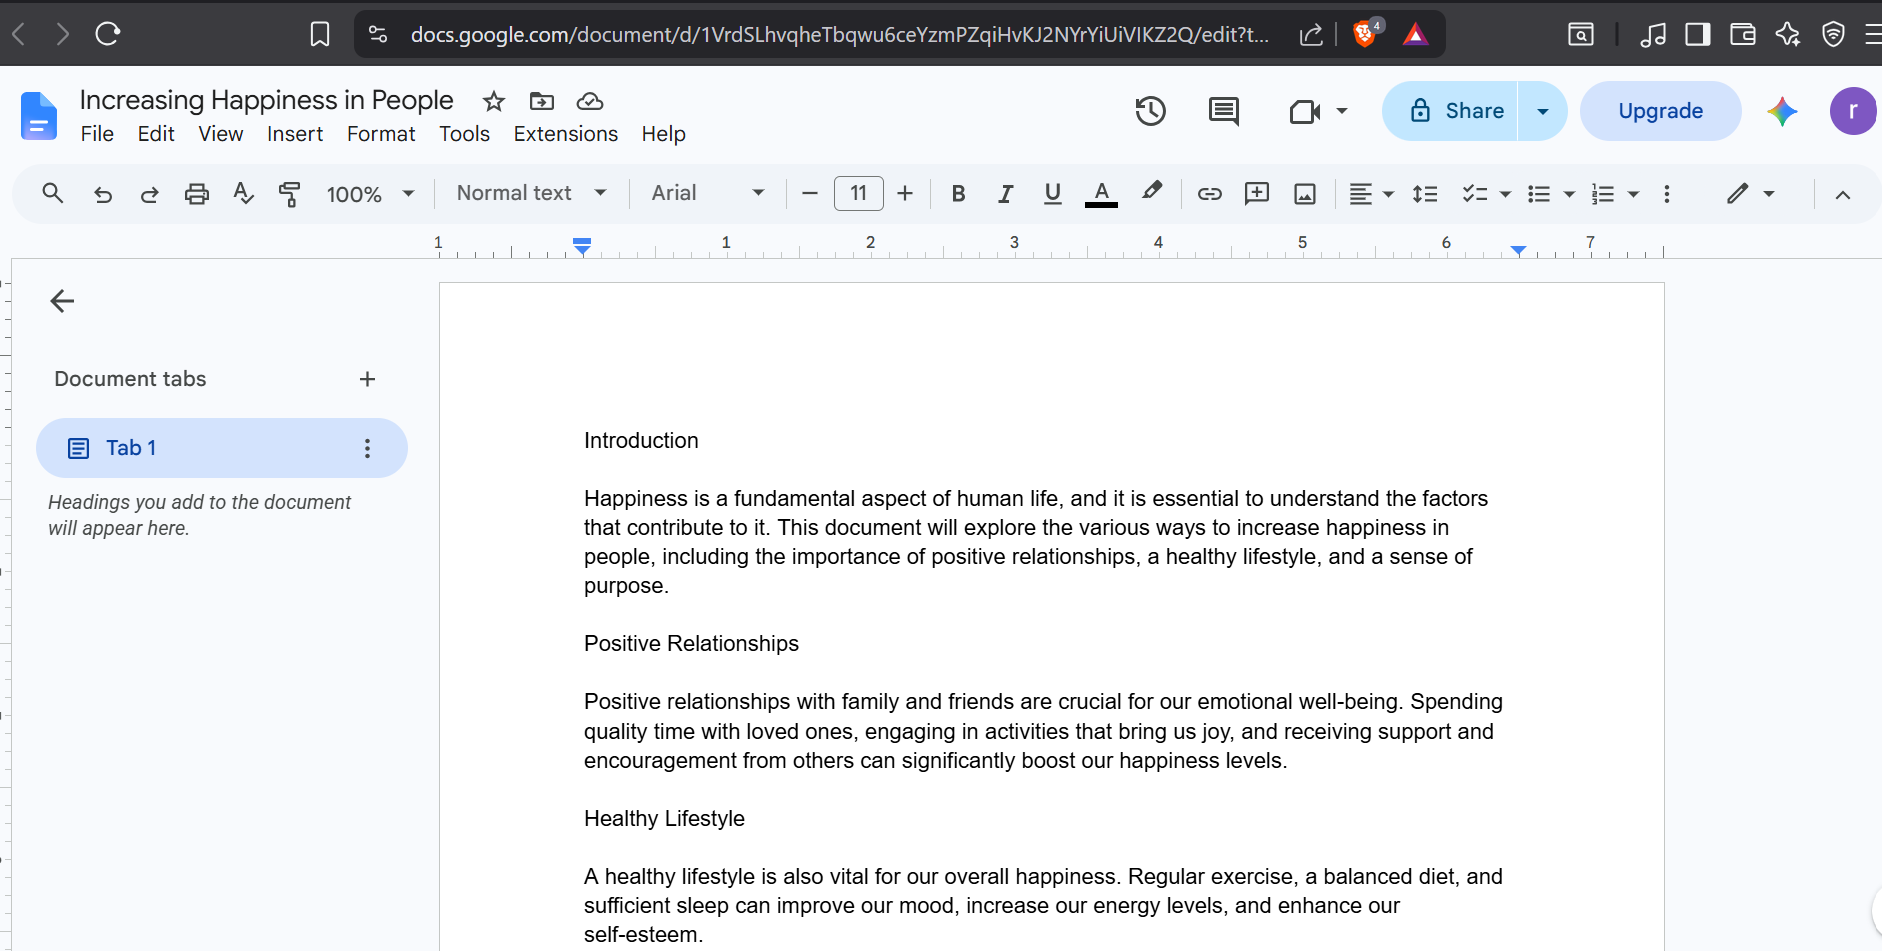